### *Imports*

In [1]:
import torch
from torch import nn, optim
from torch.amp import autocast, GradScaler
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import models
from torchvision.transforms import v2

from torchinfo import summary

from torchmetrics.classification import MultilabelAUROC

import random
import numpy as np
import pandas as pd
from PIL import Image
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

BATCH_SIZE = 32
RANDOM_SEED = 42
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

print(f"Using device: {device} | Torch version: {torch.__version__} | TorchVision version: {torchvision.__version__}")

Using device: cuda | Torch version: 2.10.0+cu128 | TorchVision version: 0.25.0+cu128


In [2]:
print("GPU count:", torch.cuda.device_count())

for i in range(torch.cuda.device_count()):
    print(i, torch.cuda.get_device_name(i))

GPU count: 2
0 Tesla T4
1 Tesla T4


### *Data Exploration & Preparation*

In [3]:
data_entry = pd.read_csv("/kaggle/input/datasets/nih-chest-xrays/data/Data_Entry_2017.csv")
print(f"There are {len(data_entry)} images in the data set.")

data_entry.head()

There are 112120 images in the data set.


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [4]:
images_counts = []
all_images = {}
for i in range(12):
    formated_counter = f"{(i + 1):03d}"
    folder_name = "images_" + str(formated_counter)
    
    dir_path = Path("/kaggle/input/datasets/nih-chest-xrays/data")
    dir_path = dir_path / folder_name / "images"

    print(f"Processing folder at path: {dir_path}")
    images_count = 0
    
    for file in dir_path.iterdir():
        all_images[file.name] = file
        images_count += 1
        
    print(f"Number of images in {folder_name}: {images_count} | Total number of images: {len(all_images)}")
    print("-" * 100)
    images_counts.append(images_count)

Processing folder at path: /kaggle/input/datasets/nih-chest-xrays/data/images_001/images
Number of images in images_001: 4999 | Total number of images: 4999
----------------------------------------------------------------------------------------------------
Processing folder at path: /kaggle/input/datasets/nih-chest-xrays/data/images_002/images
Number of images in images_002: 10000 | Total number of images: 14999
----------------------------------------------------------------------------------------------------
Processing folder at path: /kaggle/input/datasets/nih-chest-xrays/data/images_003/images
Number of images in images_003: 10000 | Total number of images: 24999
----------------------------------------------------------------------------------------------------
Processing folder at path: /kaggle/input/datasets/nih-chest-xrays/data/images_004/images
Number of images in images_004: 10000 | Total number of images: 34999
---------------------------------------------------------------

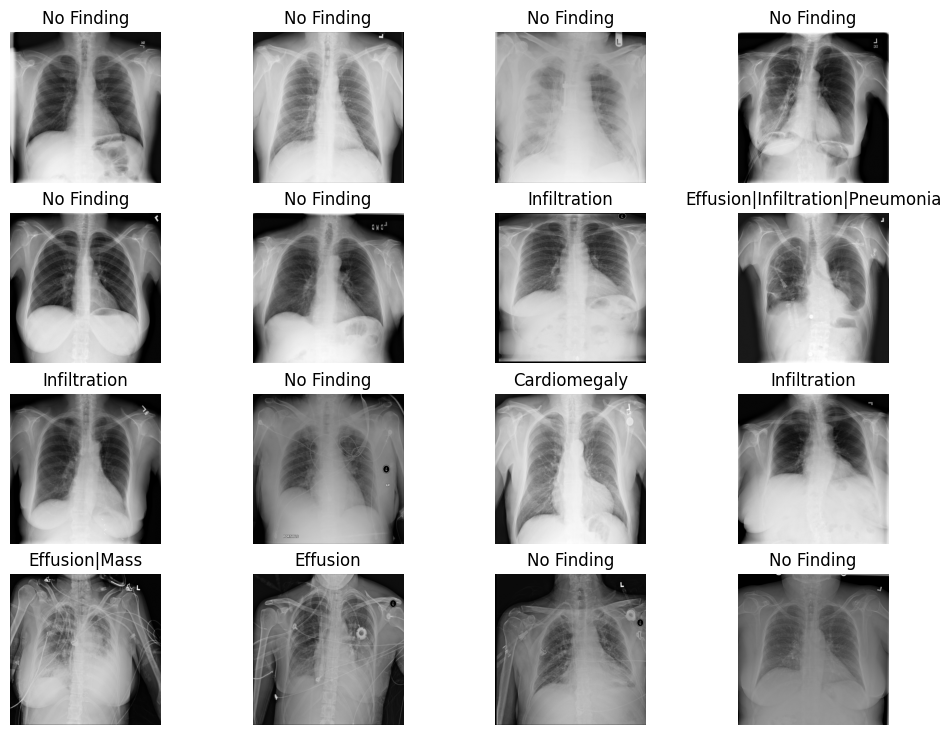

In [5]:
fig = plt.figure(figsize = (12, 9))
n_rows, n_cols = 4, 4

viz_images = random.sample(list(all_images.keys()), k = 16)
for i in range(1, n_rows * n_cols + 1):
    image_path = all_images[viz_images[i - 1]]
    
    img = Image.open(image_path)
    findings = data_entry[data_entry["Image Index"] == image_path.name]["Finding Labels"]
    
    fig.add_subplot(n_rows, n_cols, i)
    plt.imshow(img, "gray")
    plt.title(findings.item())
    plt.axis("off")
    
    

In [6]:
abnormalities = ["Atelectasis", "Cardiomegaly", "Consolidation", "Edema",
                 "Effusion", "Emphysema", "Fibrosis", "Hernia", "Infiltration",
                 "Mass", "Nodule", "Pleural_Thickening", "Pneumonia", "Pneumothorax"]

abnormalities_df = pd.DataFrame(data_entry["Finding Labels"].str.get_dummies(sep = '|'))
abnormalities_df

,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,Mass,No Finding,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax
0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0
2,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112115,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
112116,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
112117,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
112118,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0


In [7]:
cols_to_drop = ["No Finding", "Finding Labels", "Follow-up #",
                "Patient Age", "Patient Gender", "View Position",
                "OriginalImage[Width", "Height]", "OriginalImagePixelSpacing[x",
                "y]", "Unnamed: 11"]

encoded_df = pd.concat([data_entry, abnormalities_df], axis = 1)
encoded_df.drop(columns = cols_to_drop, inplace = True)
encoded_df.head()

,Image Index,Patient ID,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,Mass,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax
0,00000001_000.png,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1,00000001_001.png,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0
2,00000001_002.png,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0
3,00000002_000.png,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,00000003_000.png,3,0,0,0,0,0,0,0,1,0,0,0,0,0,0


In [8]:
n_abn = len(abnormalities)
n_patients = len(encoded_df)

abn_percentage = {}
for abnormality in abnormalities:
    count = np.sum(encoded_df[abnormality])
    abn_percentage[abnormality] = (count / n_patients) * 100

abn_percentage

{'Atelectasis': np.float64(10.309489832322512),
 'Cardiomegaly': np.float64(2.4759186585800927),
 'Consolidation': np.float64(4.16250445950767),
 'Edema': np.float64(2.054049232964681),
 'Effusion': np.float64(11.877452729218694),
 'Emphysema': np.float64(2.244024259721727),
 'Fibrosis': np.float64(1.5037459864430966),
 'Hernia': np.float64(0.20246164823403495),
 'Infiltration': np.float64(17.743489118801286),
 'Mass': np.float64(5.1569746699964325),
 'Nodule': np.float64(5.646628612201213),
 'Pleural_Thickening': np.float64(3.0190866928291116),
 'Pneumonia': np.float64(1.2763110952550838),
 'Pneumothorax': np.float64(4.728861933642526)}

Text(0.5, 1.0, 'Abnormality Presence Percentage')

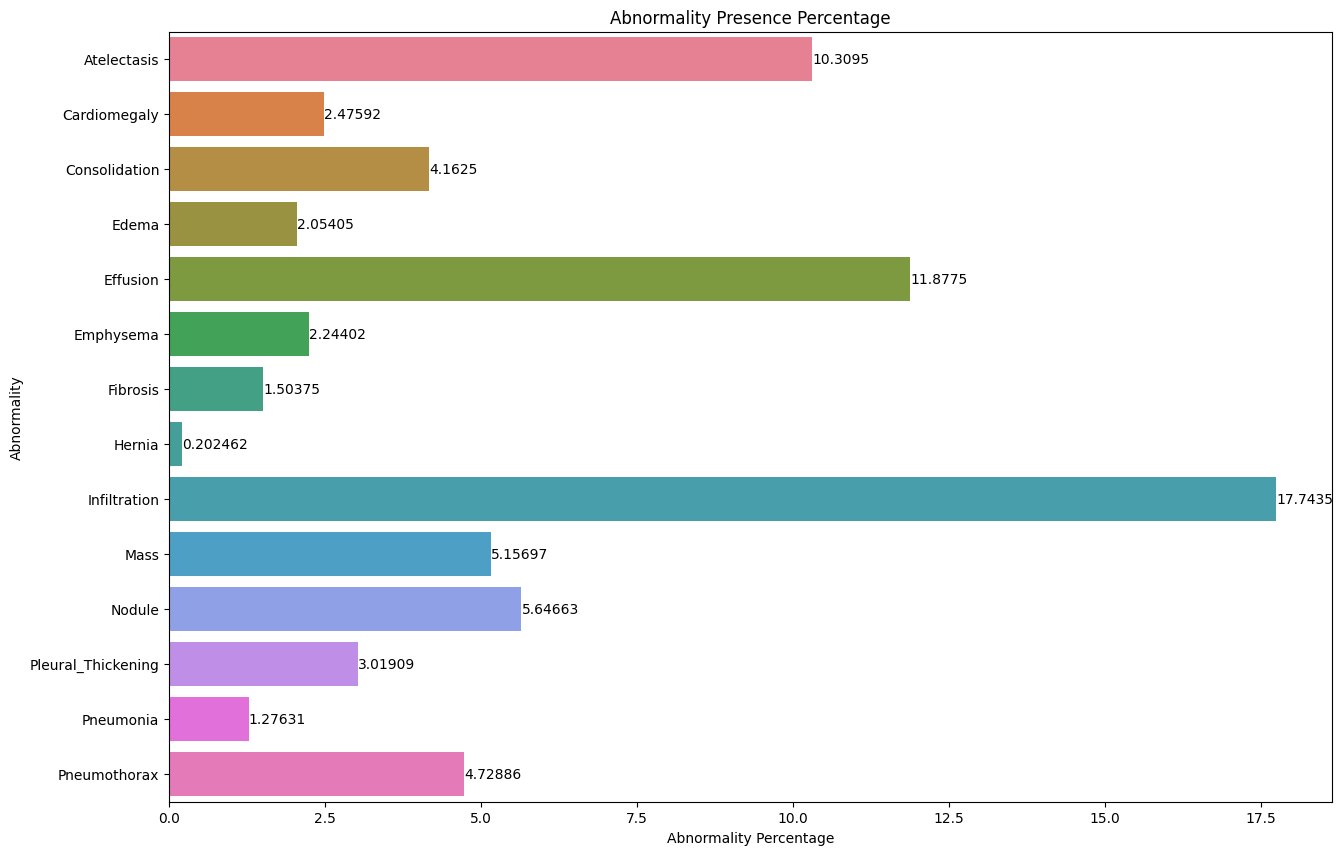

In [9]:
plt.figure(figsize = (15, 10))

ax = sns.barplot(abn_percentage, x = abn_percentage.values(), y = abn_percentage.keys(), hue = abn_percentage.keys())

for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.xlabel("Abnormality Percentage")
plt.ylabel("Abnormality")
plt.title("Abnormality Presence Percentage")

In [10]:
pos_ratio = torch.tensor(list(abn_percentage.values())) / 100
neg_ratio = 1 - pos_ratio

weights_ratio = neg_ratio / pos_ratio

weights_ratio

tensor([  8.6998,  39.3890,  23.0240,  47.6843,   7.4193,  43.5628,  65.5006,
        492.9207,   4.6359,  18.3912,  16.7097,  32.1226,  77.3508,  20.1467],
       dtype=torch.float64)

### *Leakage Check and DataFrames Creation*

In [11]:
with open("/kaggle/input/datasets/nih-chest-xrays/data/test_list.txt", "r") as test_file:
    test_list = test_file.read().splitlines()

with open("/kaggle/input/datasets/nih-chest-xrays/data/train_val_list.txt", "r") as train_val_file:
    train_val_list = train_val_file.read().splitlines()

print(f"Number of training and validating images: {len(train_val_list)} | Number of testing images: {len(test_list)} | Total number of images: {n_patients}")
print(f"Number of training, validating and testing images matches the size of the total data set: {(len(train_val_list) + len(test_list)) == n_patients}")

Number of training and validating images: 86524 | Number of testing images: 25596 | Total number of images: 112120
Number of training, validating and testing images matches the size of the total data set: True


In [12]:
test_df = encoded_df[
    encoded_df["Image Index"].isin(test_list)
]

test_patient_ids = set(test_df["Patient ID"])

In [13]:
train_val_df = encoded_df[
    encoded_df["Image Index"].isin(train_val_list)
]

train_val_patient_ids = set(train_val_df["Patient ID"])

In [14]:
print(f"A patient ID is found both the train_val set and test set: {not train_val_patient_ids.isdisjoint(test_patient_ids)}")

A patient ID is found both the train_val set and test set: False


In [15]:
random.seed(RANDOM_SEED)

train_patient_ids = set(random.sample(list(train_val_patient_ids), k = int(0.75 * len(train_val_patient_ids))))
val_patient_ids = train_val_patient_ids - train_patient_ids

list(train_patient_ids)[0:5], list(val_patient_ids)[0:5]

([1, 4, 5, 6, 7], [2, 9, 15, 17, 18])

In [16]:
train_df = train_val_df[
    train_val_df["Patient ID"].isin(train_patient_ids)
]

val_df = train_val_df[
    train_val_df["Patient ID"].isin(val_patient_ids)
]

In [17]:
print(f"A patient ID is found both the training set and validation set: {not set(train_df['Patient ID']).isdisjoint(set(val_df['Patient ID']))}")

A patient ID is found both the training set and validation set: False


### *Write the Data Set Class*

In [18]:
class ChestXrayDataset(Dataset):
    def __init__(
        self,
        df: pd.DataFrame,
        transform: torchvision.transforms = None,
        all_images: dict = all_images
    ):
        super().__init__()

        self.dataframe = df
        self.transform = transform
        self.images_paths = all_images

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(
        self,
        index
    ):
        image_name = self.dataframe["Image Index"].iloc[index]
        image_path = self.images_paths[image_name]

        img = Image.open(image_path).convert("RGB")
        findings = torch.tensor(self.dataframe.iloc[index].drop(["Image Index", "Patient ID"]).tolist())

        if self.transform:
            img = self.transform(img)

        return img, findings

### *Define the Transforms*

In [19]:
train_transform = v2.Compose([
    v2.Resize((224, 224)),

    # Minor rotations to account for patients slight tilting
    v2.RandomRotation(degrees = (-10, 10)),

    # Small translations to account for slight off-center patient position
    v2.RandomAffine(degrees = 0, translate = (0.05, 0.05)),

    # Subtle contrast/brightness adjustments to account for different X-ray machine calibrations
    v2.ColorJitter(brightness = 0.1, contrast = 0.1),

    v2.ToImage(),
    v2.ToDtype(dtype = torch.float32, scale = True),

    # Normalize using ImageNet statistics
    v2.Normalize(
        mean = [0.485, 0.456, 0.406],
        std = [0.229, 0.224, 0.225]
    )
])

val_test_transform = v2.Compose([
    v2.Resize((224, 224)),

    v2.ToImage(),
    v2.ToDtype(dtype = torch.float32, scale = True),

    v2.Normalize(
        mean = [0.485, 0.456, 0.406],
        std = [0.229, 0.224, 0.225]
    )
])

### *Datasets & DataLoaders*

In [20]:
train_dataset = ChestXrayDataset(
    df = train_df,
    transform = train_transform
)

val_dataset = ChestXrayDataset(
    df = val_df,
    transform = val_test_transform
)

test_dataset = ChestXrayDataset(
    df = test_df,
    transform = val_test_transform
)

In [21]:
train_dataloader = DataLoader(
    dataset = train_dataset,
    batch_size = BATCH_SIZE,
    shuffle = True,
    num_workers=4,
    pin_memory=True
)

val_dataloader = DataLoader(
    dataset = val_dataset,
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers=4,
    pin_memory=True
)

test_dataloader = DataLoader(
    dataset = test_dataset,
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers=4,
    pin_memory=True
)

print(f"Number of batches in training dataloader: {len(train_dataloader)}")
print(f"Number of batches in validation dataloader: {len(val_dataloader)}")
print(f"Number of batches in testing dataloader: {len(test_dataloader)}")

Number of batches in training dataloader: 2050
Number of batches in validation dataloader: 654
Number of batches in testing dataloader: 800


In [22]:
images_batch, labels_batch = next(iter(train_dataloader))
print(f"Images Batch Size: {images_batch.shape} | Labels Batch Size: {labels_batch.shape}")

Images Batch Size: torch.Size([32, 3, 224, 224]) | Labels Batch Size: torch.Size([32, 14])


### *Prepare the Model*

In [23]:
model = models.get_model("densenet121", weights = "DEFAULT").to(device)
model.classifier = nn.Linear(
    in_features = model.classifier.in_features,
    out_features = n_abn
).to(device)

model_summary = summary(
    model = model,
    input_size = images_batch.shape,
    col_names = ["input_size", "output_size", "num_params", "trainable"],
    row_settings = ["var_names"]
)

model_summary

Layer (type (var_name))                       Input Shape               Output Shape              Param #                   Trainable
DenseNet (DenseNet)                           [32, 3, 224, 224]         [32, 14]                  --                        True
├─Sequential (features)                       [32, 3, 224, 224]         [32, 1024, 7, 7]          --                        True
│    └─Conv2d (conv0)                         [32, 3, 224, 224]         [32, 64, 112, 112]        9,408                     True
│    └─BatchNorm2d (norm0)                    [32, 64, 112, 112]        [32, 64, 112, 112]        128                       True
│    └─ReLU (relu0)                           [32, 64, 112, 112]        [32, 64, 112, 112]        --                        --
│    └─MaxPool2d (pool0)                      [32, 64, 112, 112]        [32, 64, 56, 56]          --                        --
│    └─_DenseBlock (denseblock1)              [32, 64, 56, 56]          [32, 256, 56, 56]       

In [24]:
# Wrap in DataParallel if more than one GPU is visible (e.g. Kaggle's GPU T4 x2)
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs via DataParallel")
    model = nn.DataParallel(model)

model = model.to(device)

# Helper to reach the underlying model whether or not it's wrapped in DataParallel
base_model = model.module if isinstance(model, nn.DataParallel) else model

Using 2 GPUs via DataParallel


In [ ]:
# Look for a previously saved checkpoint and resume from it if one exists.
CHECKPOINT_PATH = Path("/kaggle/input/datasets/ahmedmoety/model-checkpoint-3/NIH Chest X-Ray model.pt")

checkpoint = None

if CHECKPOINT_PATH.exists():
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
    base_model.load_state_dict(checkpoint["model_state_dict"])
    print(
        f"Found checkpoint from epoch {checkpoint['epoch'] + 1} "
        f"(best Macro AUROC so far: {checkpoint['best_macro_auroc']:.4f}) — resuming training."
    )
else:
    print("No checkpoint found — starting training from scratch.")

RESUME_TRAINING = checkpoint is not None

### *Focal Loss*

In [25]:
class MultilabelFocalLoss(nn.Module):
    """
    Focal loss for multi-label classification.

    Combines two complementary ways of handling class imbalance:
      - `pos_weight` (per-class): up-weights positive examples for rare
        findings, same as plain BCEWithLogitsLoss.
      - focal modulation `(1 - p_t) ** gamma`: down-weights *easy*,
        already-well-classified examples (regardless of class) so the
        model spends more gradient signal on hard cases.
    """

    def __init__(self, pos_weight=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.gamma = gamma
        self.reduction = reduction
        self.register_buffer("pos_weight", pos_weight)

    def forward(self, logits, targets):
        bce_loss = F.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=self.pos_weight, reduction="none"
        )

        probs = torch.sigmoid(logits)
        p_t = probs * targets + (1 - probs) * (1 - targets)
        focal_term = (1 - p_t) ** self.gamma

        loss = focal_term * bce_loss

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        return loss


FOCAL_GAMMA = 2.0

In [26]:
loss_fn = MultilabelFocalLoss(
    pos_weight = weights_ratio.to(device),
    gamma = FOCAL_GAMMA
).to(device)

optimizer_wu = optim.AdamW(
    params = model.parameters(),
    lr = 1e-3
)

### *Warm-Up Phase*

In [ ]:
# Freeze the backbone (skip if resuming — the checkpoint was already saved post-unfreeze)
if not RESUME_TRAINING:
    for param in base_model.features.parameters():
        param.requires_grad = False

In [ ]:
if not RESUME_TRAINING:
    NUM_EPOCHS_WU = 2
    scaler = GradScaler("cuda")

    macro_auroc_wu = MultilabelAUROC(
        num_labels=n_abn,
        average="macro"
    ).to(device)


    for epoch in tqdm(range(NUM_EPOCHS_WU)):

        # ==========================================
        # TRAINING
        # ==========================================

        model.train()

        total_train_loss = 0.0

        for images, labels in train_dataloader:

            images = images.to(device, non_blocking=True)
            labels = labels.float().to(device, non_blocking=True)

            optimizer_wu.zero_grad()

            with autocast(device_type = "cuda", dtype = torch.float16):
                y_logits = model(images)
                train_loss = loss_fn(y_logits, labels)

            total_train_loss += train_loss.item()

            # Backpropagation
            scaler.scale(train_loss).backward()

            scaler.step(optimizer_wu)

            scaler.update()

        avg_train_loss = total_train_loss / len(train_dataloader)


        # ==========================================
        # VALIDATION
        # ==========================================

        macro_auroc_wu.reset()

        model.eval()

        total_val_loss = 0.0

        with torch.no_grad():

            for images, labels in val_dataloader:

                images = images.to(device, non_blocking=True)
                labels = labels.float().to(device, non_blocking=True)

                with autocast(device_type = "cuda", dtype = torch.float16):
                    y_logits = model(images)
                    val_loss = loss_fn(y_logits, labels)

                y_logits = y_logits.float()
                total_val_loss += val_loss.item()

                macro_auroc_wu.update(y_logits, labels.long())

        avg_val_loss = total_val_loss / len(val_dataloader)

        macro_auroc = macro_auroc_wu.compute()

        print(
            f"Epoch: {epoch + 1} | "
            f"Macro AUROC: {macro_auroc.item():.4f} | "
            f"Training Loss: {avg_train_loss:.4f} | "
            f"Validation Loss: {avg_val_loss:.4f}"
        )
else:
    print("Resuming from a checkpoint — skipping warm-up phase.")

### *Training Phase*

In [28]:
# Unfreeze the model
for param in base_model.features.parameters():
    param.requires_grad = True

In [27]:
loss_fn = MultilabelFocalLoss(
    pos_weight = weights_ratio.to(device),
    gamma = FOCAL_GAMMA
).to(device)

# Discriminative learning rates: the pretrained backbone gets a small LR
# (it already has good features, needs gentle fine-tuning), while the
# randomly-initialized classifier head gets a larger one so it can catch up.
optimizer_t = optim.AdamW(
    [
        {
            "params": base_model.features.parameters(),
            "lr": 1e-5
        },
        {
            "params": base_model.classifier.parameters(),
            "lr": 1e-4
        }
    ],
    weight_decay = 1e-4
)

In [ ]:
NUM_EPOCHS_T = 50

best_macro_auroc = 0.0
start_epoch = 0

patience = 5
epochs_without_improvement = 0

macro_auroc_t = MultilabelAUROC(
    num_labels=n_abn,
    average="macro"
).to(device)

scaler = GradScaler("cuda")

if RESUME_TRAINING:
    optimizer_t.load_state_dict(checkpoint["optimizer_state_dict"])
    scaler.load_state_dict(checkpoint["scaler_state_dict"])
    best_macro_auroc = checkpoint["best_macro_auroc"]
    start_epoch = checkpoint["epoch"] + 1
    print(f"Resuming at epoch {start_epoch + 1} / {NUM_EPOCHS_T}.")


for epoch in tqdm(range(start_epoch, NUM_EPOCHS_T)):

    # ==================================================
    # Training
    # ==================================================

    model.train()
    total_train_loss = 0.0

    for images, labels in train_dataloader:

        images = images.to(device, non_blocking=True)
        labels = labels.float().to(device, non_blocking=True)

        optimizer_t.zero_grad(set_to_none=True)

        with autocast(device_type="cuda", dtype=torch.float16):

            y_logits = model(images)

            train_loss = loss_fn(
                y_logits,
                labels
            )

        total_train_loss += train_loss.item()

        # Backpropagation
        scaler.scale(train_loss).backward()

        scaler.step(optimizer_t)

        scaler.update()


    avg_train_loss = total_train_loss / len(train_dataloader)


    # ==================================================
    # Validation
    # ==================================================

    macro_auroc_t.reset()

    model.eval()
    total_val_loss = 0.0

    with torch.no_grad():

        for images, labels in val_dataloader:

            images = images.to(device, non_blocking=True)
            labels = labels.float().to(device, non_blocking=True)

            with autocast(device_type="cuda", dtype=torch.float16):

                y_logits = model(images)

                val_loss = loss_fn(
                    y_logits,
                    labels
                )

            total_val_loss += val_loss.item()

            # TorchMetrics receives floating-point predictions
            macro_auroc_t.update(
                y_logits.float(),
                labels.long()
            )


    avg_val_loss = total_val_loss / len(val_dataloader)

    macro_auroc = macro_auroc_t.compute().item()


    # ==================================================
    # Checkpointing
    # ==================================================

    if macro_auroc > best_macro_auroc:

        best_macro_auroc = macro_auroc

        epochs_without_improvement = 0

        torch.save({
            "epoch": epoch,
            "model_state_dict": base_model.state_dict(),
            "optimizer_state_dict": optimizer_t.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "best_macro_auroc": best_macro_auroc
        }, "NIH Chest X-Ray model.pt")

        print("  → New best model saved!")


    else:

        epochs_without_improvement += 1


    # ==================================================
    # Logging
    # ==================================================

    print(
        f"Epoch: {epoch + 1} | "
        f"Macro AUROC: {macro_auroc:.4f} | "
        f"Training Loss: {avg_train_loss:.4f} | "
        f"Validation Loss: {avg_val_loss:.4f}"
    )


    # ==================================================
    # Early stopping
    # ==================================================

    if epochs_without_improvement >= patience:

        print(
            f"Early stopping at epoch {epoch + 1}. "
            f"Best Macro AUROC: {best_macro_auroc:.4f}"
        )

        break

### *Final Model Evaluation*

To evaluate without retraining, run the cells from **Imports** down to **`base_model`** (the cell that wraps the model in `DataParallel`), **skip the checkpoint/warm-up/training cells**, and then run the cells below.

In [29]:
FINAL_MODEL_PATH = Path("/kaggle/input/datasets/ahmedmoety/trained-model/NIH Chest X-Ray model.pt")

final_checkpoint = torch.load(FINAL_MODEL_PATH, map_location=device)
base_model.load_state_dict(final_checkpoint["model_state_dict"])
model.eval()

print(
    f"Loaded final model from epoch {final_checkpoint['epoch'] + 1} "
    f"(validation Macro AUROC at save time: {final_checkpoint['best_macro_auroc']:.4f})"
)

Loaded final model from epoch 11 (validation Macro AUROC at save time: 0.8056)


In [30]:
@torch.no_grad()
def collect_predictions(dataloader):
    """Runs the model over a dataloader and returns (probabilities, labels) as numpy arrays."""
    model.eval()

    all_probs, all_labels = [], []

    for images, labels in tqdm(dataloader):
        images = images.to(device, non_blocking=True)

        with autocast(device_type="cuda", dtype=torch.float16):
            y_logits = model(images)

        all_probs.append(torch.sigmoid(y_logits.float()).cpu())
        all_labels.append(labels.long())

    return torch.cat(all_probs).numpy(), torch.cat(all_labels).numpy()


# Validation predictions are only used to choose the classification thresholds;
# every reported metric is computed on the untouched test set.
val_probs, val_labels = collect_predictions(val_dataloader)
test_probs, test_labels = collect_predictions(test_dataloader)

print(f"Validation: {val_probs.shape} | Test: {test_probs.shape}")

  0%|          | 0/654 [00:00<?, ?it/s]

  0%|          | 0/800 [00:00<?, ?it/s]

Validation: (20927, 14) | Test: (25596, 14)


In [31]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score
)


def find_best_thresholds(probs, labels):
    """Per-class threshold that maximises F1 (VALIDATION set only)."""
    thresholds = np.zeros(labels.shape[1])

    for c in range(labels.shape[1]):
        precision, recall, thr = precision_recall_curve(labels[:, c], probs[:, c])

        # precision/recall have one more entry than thr, so drop the last point
        f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
        thresholds[c] = thr[np.argmax(f1)]

    return thresholds


def compute_metrics(probs, labels, thresholds, class_names):
    preds = (probs >= thresholds).astype(int)

    results = pd.DataFrame({
        "AUROC":      roc_auc_score(labels, probs, average=None),
        "Precision":  precision_score(labels, preds, average=None, zero_division=0),
        "Recall":     recall_score(labels, preds, average=None, zero_division=0),
        "F1":         f1_score(labels, preds, average=None, zero_division=0),
        "AUPRC":      average_precision_score(labels, probs, average=None),
        "Threshold":  thresholds,
        "Prevalence": labels.mean(axis=0)
    }, index=class_names)

    # Macro = unweighted mean over the 14 classes
    metric_cols = ["AUROC", "Precision", "Recall", "F1", "AUPRC"]
    results.loc["Macro"] = results[metric_cols].mean()

    return results

In [32]:
tuned_thresholds = find_best_thresholds(val_probs, val_labels)
fixed_thresholds = np.full(n_abn, 0.5)

results_tuned = compute_metrics(test_probs, test_labels, tuned_thresholds, abnormalities)
results_fixed = compute_metrics(test_probs, test_labels, fixed_thresholds, abnormalities)

print("Test set metrics | thresholds tuned per class on the validation set (max F1)")
display(results_tuned.round(4))

print("\nTest set metrics | fixed threshold of 0.5 for every class")
display(results_fixed.round(4))

print(
    f"\nMacro AUROC: {results_tuned.loc['Macro', 'AUROC']:.4f} | "
    f"Macro AUPRC: {results_tuned.loc['Macro', 'AUPRC']:.4f} | "
    f"Macro F1 (tuned thresholds): {results_tuned.loc['Macro', 'F1']:.4f} | "
    f"Macro F1 (0.5 thresholds): {results_fixed.loc['Macro', 'F1']:.4f}"
)

results_tuned.round(4).to_csv("test_metrics_tuned_thresholds.csv")
results_fixed.round(4).to_csv("test_metrics_fixed_0.5_threshold.csv")

Test set metrics | thresholds tuned per class on the validation set (max F1)


,AUROC,Precision,Recall,F1,AUPRC,Threshold,Prevalence
Atelectasis,0.7357,0.2527,0.5965,0.3550,0.2936,0.5602,0.1281
Cardiomegaly,0.8626,0.3303,0.4060,0.3642,0.2950,0.6937,0.0418
Consolidation,0.7048,0.1314,0.5383,0.2113,0.1340,0.5617,0.0709
Edema,0.8277,0.1540,0.4151,0.2246,0.1445,0.7199,0.0361
Effusion,0.7949,0.3706,0.7005,0.4848,0.4469,0.5400,0.1820
Emphysema,0.8604,0.2974,0.4465,0.3570,0.2877,0.6794,0.0427
Fibrosis,0.7779,0.0906,0.1149,0.1013,0.0636,0.7081,0.0170
Hernia,0.8907,0.7500,0.1744,0.2830,0.2950,0.9192,0.0034
Infiltration,0.6795,0.3044,0.8084,0.4423,0.3736,0.4923,0.2388
Mass,0.7469,0.2223,0.3484,0.2715,0.2069,0.6008,0.0683



Test set metrics | fixed threshold of 0.5 for every class


,AUROC,Precision,Recall,F1,AUPRC,Threshold,Prevalence
Atelectasis,0.7357,0.1962,0.8024,0.3153,0.2936,0.5,0.1281
Cardiomegaly,0.8626,0.1441,0.7558,0.2421,0.2950,0.5,0.0418
Consolidation,0.7048,0.1106,0.7895,0.1940,0.1340,0.5,0.0709
Edema,0.8277,0.0789,0.8876,0.1450,0.1445,0.5,0.0361
Effusion,0.7949,0.3314,0.8081,0.4701,0.4469,0.5,0.1820
Emphysema,0.8604,0.1684,0.7274,0.2735,0.2877,0.5,0.0427
Fibrosis,0.7779,0.0443,0.6345,0.0828,0.0636,0.5,0.0170
Hernia,0.8907,0.1408,0.4651,0.2162,0.2950,0.5,0.0034
Infiltration,0.6795,0.3132,0.7814,0.4471,0.3736,0.5,0.2388
Mass,0.7469,0.1438,0.6527,0.2356,0.2069,0.5,0.0683



Macro AUROC: 0.7732 | Macro AUPRC: 0.2315 | Macro F1 (tuned thresholds): 0.2865 | Macro F1 (0.5 thresholds): 0.2490
